# Corrección Weibull de interacciones

## Qué hace este notebook

Toma `redes_unificadas.csv` (interacciones scrapeadas en 2026) y produce
`redes_unificadas_descontadas.csv` con **exactamente la misma estructura**,
pero donde cada valor de interacción refleja la estimación de cuántas
interacciones tenía cada publicación el **día anterior a la elección**
(28 oct 2023), no hoy.

## Por qué es necesario

Las publicaciones fueron scrapeadas en 2026, más de 2 años después de la
elección. En ese tiempo las interacciones siguieron creciendo — y los
ganadores acumularon más interacciones post-victoria que los perdedores.
Usar los valores crudos introduce un sesgo que hace el modelo parcialmente
dependiente de información post-electoral.

## Fórmula

Para cada publicación con `t_pub` días antes de la elección y `t_scrap`
días antes del scraping:

$$x_{\text{corregido}} = x_{\text{actual}} \times \frac{F(t_{\text{elec}})}{F(t_{\text{scrap}})}$$

donde $F(t) = 1 - e^{-k(t + t_0)^\alpha}$ con parámetros calibrados
en Costa Rica 2026 por plataforma.

## Output

`resultados/redes_unificadas_descontadas.csv` — misma estructura que el
original, listos para reemplazarlo en todos los notebooks de modelado.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 4)
AZUL = '#1A2F6F'
print('Librerías cargadas.')

Librerías cargadas.


## 1. Configuración

Ajusta las rutas y fechas si es necesario. Lo demás no debería tocarse.

In [2]:
# ── Rutas ──────────────────────────────────────────────────────────────────
base_path    = os.getcwd()   # carpeta Herramientas/
INPUT_CSV    = os.path.join(base_path, 'resultados', 'redes_unificadas.csv')
OUTPUT_CSV   = os.path.join(base_path, 'resultados', 'redes_unificadas_descontadas.csv')
SEP          = ';'
ENCODING     = 'utf-8-sig'

# ── Fechas clave ───────────────────────────────────────────────────────────
FECHA_ELECCION = pd.Timestamp('2023-10-29')   # día de la elección Colombia
# Día en que corriste el scraping. Ajusta al mes correcto si lo sabes.
# Si no recuerdas la fecha exacta, usa el 1 del mes aproximado.
FECHA_SCRAPING = pd.Timestamp('2026-04-01')   # ← AJUSTA AQUÍ

# ── Columnas de interacción a corregir ────────────────────────────────────
# Todas las que existan en el CSV serán corregidas; las que no existan
# se ignoran sin error.
COLS_INTERACCION = [
    'likes', 'comentarios', 'compartidos', 'vistas', 'favoritos',
    'fb_love', 'fb_haha', 'fb_care', 'fb_wow', 'fb_sad', 'fb_angry',
]

print(f'Input  → {INPUT_CSV}')
print(f'Output → {OUTPUT_CSV}')
print(f'Elección : {FECHA_ELECCION.date()}')
print(f'Scraping : {FECHA_SCRAPING.date()}')
print(f'Ventana  : {(FECHA_SCRAPING - FECHA_ELECCION).days} días entre elección y scraping')

Input  → c:\Users\juansoag\Downloads\Avances_tesis (modificado)\Herramientas\resultados\redes_unificadas.csv
Output → c:\Users\juansoag\Downloads\Avances_tesis (modificado)\Herramientas\resultados\redes_unificadas_descontadas.csv
Elección : 2023-10-29
Scraping : 2026-04-01
Ventana  : 885 días entre elección y scraping


## 2. Parámetros Weibull

Calibrados sobre el panel de Costa Rica 2026
(`Modelado_Crecimiento_Interacciones_v4.ipynb`).
Si se recalibran, actualiza el diccionario `WEIBULL` aquí.

In [3]:
# k, alpha, t0  —  F(t) = 1 - exp(-k * (t + t0)^alpha)
WEIBULL = {
    'Facebook':  {'k': 0.9480, 'alpha': 0.8230, 't0': 1.9323},
    'Twitter':   {'k': 1.4453, 'alpha': 1.1422, 't0': 0.2566},
    'TikTok':    {'k': 1.3272, 'alpha': 0.5124, 't0': 0.7887},
    'Instagram': {'k': 1.1369, 'alpha': 0.5210, 't0': 0.0408},
}

# Para plataformas no reconocidas: promedio de los cuatro conjuntos
WEIBULL_DEFAULT = {
    'k':     np.mean([p['k']     for p in WEIBULL.values()]),
    'alpha': np.mean([p['alpha'] for p in WEIBULL.values()]),
    't0':    np.mean([p['t0']    for p in WEIBULL.values()]),
}

# Aliases de nombres de plataforma tal como aparecen en red_social
PLATFORM_ALIASES = {
    'facebook': 'Facebook',
    'twitter':  'Twitter',
    'x':        'Twitter',
    'tiktok':   'TikTok',
    'instagram':'Instagram',
}

print('Parámetros Weibull:')
for plat, p in WEIBULL.items():
    print(f'  {plat:12s}  k={p["k"]:.4f}  alpha={p["alpha"]:.4f}  t0={p["t0"]:.4f}')
print(f'  {"DEFAULT":12s}  k={WEIBULL_DEFAULT["k"]:.4f}  '
      f'alpha={WEIBULL_DEFAULT["alpha"]:.4f}  t0={WEIBULL_DEFAULT["t0"]:.4f}')

Parámetros Weibull:
  Facebook      k=0.9480  alpha=0.8230  t0=1.9323
  Twitter       k=1.4453  alpha=1.1422  t0=0.2566
  TikTok        k=1.3272  alpha=0.5124  t0=0.7887
  Instagram     k=1.1369  alpha=0.5210  t0=0.0408
  DEFAULT       k=1.2144  alpha=0.7496  t0=0.7546


## 3. Carga del CSV original

In [4]:
df = pd.read_csv(INPUT_CSV, sep=SEP, encoding=ENCODING)
print(f'Filas: {len(df):,}  |  Columnas: {len(df.columns)}')
print(f'Candidatos únicos: {df["id_candidato"].nunique()}')
print(f'Plataformas: {df["red_social"].value_counts().to_dict()}')

cols_presentes = [c for c in COLS_INTERACCION if c in df.columns]
cols_ausentes  = [c for c in COLS_INTERACCION if c not in df.columns]
print(f'\nColumnas de interacción presentes : {cols_presentes}')
if cols_ausentes:
    print(f'Columnas de interacción ausentes  : {cols_ausentes} (se ignoran)')

Filas: 8,824  |  Columnas: 18
Candidatos únicos: 123
Plataformas: {'Facebook': 4622, 'Twitter': 2682, 'TikTok': 1520}

Columnas de interacción presentes : ['likes', 'comentarios', 'compartidos', 'vistas', 'favoritos', 'fb_love', 'fb_haha', 'fb_care', 'fb_wow', 'fb_sad', 'fb_angry']


## 4. Cálculo del factor de corrección

Para cada publicación calculamos cuántos días habían pasado desde su
publicación hasta la elección (`t_elec`) y hasta el scraping (`t_scrap`).
El factor de corrección es `F(t_elec) / F(t_scrap)`.

In [5]:
def weibull_F(t, k, alpha, t0):
    """Fracción acumulada de interacciones al tiempo t (días desde publicación)."""
    t_eff = np.maximum(np.asarray(t, dtype=float) + t0, 1e-9)
    return 1.0 - np.exp(-k * np.power(t_eff, alpha))


# --- Parsear fecha de publicación ----------------------------------------
if 'fecha' in df.columns and 'hora' in df.columns:
    df['_fecha_pub'] = pd.to_datetime(
        df['fecha'].astype(str) + ' ' + df['hora'].astype(str),
        errors='coerce'
    )
elif 'fecha' in df.columns:
    df['_fecha_pub'] = pd.to_datetime(df['fecha'], errors='coerce')
else:
    raise ValueError("El CSV no tiene columna 'fecha'. Verifica el archivo.")

n_sin_fecha = df['_fecha_pub'].isna().sum()
if n_sin_fecha:
    print(f'⚠  {n_sin_fecha} filas sin fecha parseable — factor = 1 (sin corrección).')

# --- Mapear plataforma ---------------------------------------------------
df['_platform'] = (
    df['red_social'].astype(str).str.strip().str.lower()
    .map(PLATFORM_ALIASES)
)
n_unk = df['_platform'].isna().sum()
if n_unk:
    vals = df.loc[df['_platform'].isna(), 'red_social'].unique()
    print(f'⚠  {n_unk} filas con plataforma no reconocida {vals} — se usa DEFAULT.')
    df['_platform'] = df['_platform'].fillna('__default__')

# --- Días desde publicación hasta elección y hasta scraping ---------------
df['_t_elec']  = (FECHA_ELECCION - df['_fecha_pub']).dt.total_seconds() / 86400
df['_t_scrap'] = (FECHA_SCRAPING - df['_fecha_pub']).dt.total_seconds() / 86400

# Publicaciones válidas: publicadas antes de la elección,
# con fecha parseable, y con scraping posterior a la elección
mask_valida = (
    df['_fecha_pub'].notna() &
    (df['_t_elec']  >= 0) &
    (df['_t_scrap'] > df['_t_elec'])
)

n_invalidas = (~mask_valida).sum()
if n_invalidas:
    print(f'⚠  {n_invalidas} filas fuera del rango válido — factor = 1.')

# --- Calcular factores por plataforma ------------------------------------
factores = np.ones(len(df))

all_platforms = list(WEIBULL.keys()) + ['__default__']
for plat in all_platforms:
    p = WEIBULL.get(plat, WEIBULL_DEFAULT)
    idx = df.index[mask_valida & (df['_platform'] == plat)]
    if len(idx) == 0:
        continue
    t_e = df.loc[idx, '_t_elec'].values
    t_s = df.loc[idx, '_t_scrap'].values
    F_e = weibull_F(t_e, p['k'], p['alpha'], p['t0'])
    F_s = weibull_F(t_s, p['k'], p['alpha'], p['t0'])
    with np.errstate(divide='ignore', invalid='ignore'):
        f = np.where(F_s > 1e-9, F_e / F_s, 1.0)
    # El factor no puede ser mayor que 1 ni negativo
    f = np.clip(f, 0.0, 1.0)
    pos = df.index.get_indexer(idx)
    factores[pos] = f

df['_factor'] = factores

# --- Resumen -------------------------------------------------------------
f_validos = factores[mask_valida.values]
print(f'\n✓ Factores calculados para {mask_valida.sum():,} publicaciones válidas')
print(f'  Mediana : {np.median(f_validos):.4f}')
print(f'  Media   : {np.mean(f_validos):.4f}')
print(f'  Mín     : {np.min(f_validos):.4f}')
print(f'  Máx     : {np.max(f_validos):.4f}')
print(f'\n  Interpretación: un factor de {np.median(f_validos):.2f} significa que al día')
print(f'  de la elección las publicaciones tenían el {np.median(f_validos)*100:.0f}% de')
print(f'  las interacciones que acumularon hasta el scraping.')

⚠  83 filas sin fecha parseable — factor = 1 (sin corrección).
⚠  405 filas fuera del rango válido — factor = 1.

✓ Factores calculados para 8,419 publicaciones válidas
  Mediana : 0.9948
  Media   : 0.9601
  Mín     : 0.2671
  Máx     : 1.0000

  Interpretación: un factor de 0.99 significa que al día
  de la elección las publicaciones tenían el 99% de
  las interacciones que acumularon hasta el scraping.


## 5. Diagnóstico visual

Distribución de factores por plataforma.

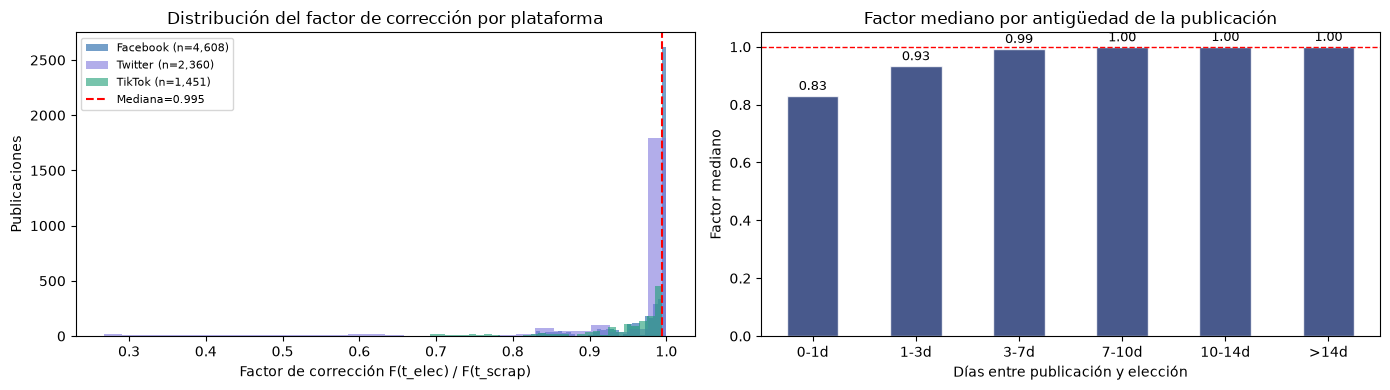

✓ Figura guardada en resultados/diagnostico_weibull.png


In [6]:
COLORES = {
    'Facebook': '#185FA5', 'Twitter': '#7F77DD',
    'TikTok': '#1D9E75', 'Instagram': '#D85A30',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma de factores por plataforma
ax = axes[0]
for plat, color in COLORES.items():
    mask = mask_valida & (df['_platform'] == plat)
    if mask.sum() == 0:
        continue
    ax.hist(df.loc[mask, '_factor'], bins=30, alpha=0.6,
            color=color, label=f'{plat} (n={mask.sum():,})')
ax.axvline(np.median(f_validos), color='red', lw=1.5,
           linestyle='--', label=f'Mediana={np.median(f_validos):.3f}')
ax.set_xlabel('Factor de corrección F(t_elec) / F(t_scrap)')
ax.set_ylabel('Publicaciones')
ax.set_title('Distribución del factor de corrección por plataforma')
ax.legend(fontsize=8)

# Factor mediano por días desde publicación hasta elección
ax2 = axes[1]
df_validas = df[mask_valida].copy()
df_validas['_dias_bin'] = pd.cut(df_validas['_t_elec'],
                                  bins=[0, 1, 3, 7, 10, 14, np.inf],
                                  labels=['0-1d', '1-3d', '3-7d', '7-10d', '10-14d', '>14d'])
resumen_dias = df_validas.groupby('_dias_bin', observed=True)['_factor'].median()
resumen_dias.plot(kind='bar', ax=ax2, color=AZUL, alpha=0.8, edgecolor='white')
ax2.set_xlabel('Días entre publicación y elección')
ax2.set_ylabel('Factor mediano')
ax2.set_title('Factor mediano por antigüedad de la publicación')
ax2.set_ylim(0, 1.05)
ax2.axhline(1.0, color='red', lw=1, linestyle='--')
ax2.tick_params(axis='x', rotation=0)
for bar, val in zip(ax2.patches, resumen_dias):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(base_path, 'resultados', 'diagnostico_weibull.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figura guardada en resultados/diagnostico_weibull.png')

## 6. Aplicar corrección y generar CSV de salida

Misma estructura que `redes_unificadas.csv`. Solo cambian los valores
numéricos de las columnas de interacción.

In [7]:
df_out = df.drop(columns=['_fecha_pub', '_platform', '_t_elec', '_t_scrap', '_factor']).copy()

for col in cols_presentes:
    original = pd.to_numeric(df[col], errors='coerce').fillna(0).clip(lower=0)
    corregido = (original * df['_factor']).round().astype(int)
    df_out[col] = corregido

# Verificación rápida: los corregidos deben ser <= originales
for col in cols_presentes:
    orig = pd.to_numeric(df[col], errors='coerce').fillna(0)
    corr = df_out[col]
    n_mayor = (corr > orig + 1).sum()  # +1 por redondeo
    if n_mayor > 0:
        print(f'⚠  {col}: {n_mayor} filas corregidas > originales (revisar)')

# Guardar
df_out.to_csv(OUTPUT_CSV, sep=SEP, encoding=ENCODING, index=False)
print(f'\n✓ CSV guardado: {OUTPUT_CSV}')
print(f'  Filas: {len(df_out):,}  |  Columnas: {len(df_out.columns)}')


✓ CSV guardado: c:\Users\juansoag\Downloads\Avances_tesis (modificado)\Herramientas\resultados\redes_unificadas_descontadas.csv
  Filas: 8,824  |  Columnas: 18


## 7. Resumen del impacto de la corrección

In [8]:
print('=== Impacto de la corrección por columna ===')
print(f'{"Columna":15s}  {"Suma original":>15s}  {"Suma corregida":>15s}  {"Reducción":>10s}')
print('-' * 60)
for col in cols_presentes:
    orig = pd.to_numeric(df[col], errors='coerce').fillna(0).sum()
    corr = df_out[col].sum()
    if orig > 0:
        red = (1 - corr / orig) * 100
        print(f'{col:15s}  {orig:>15,.0f}  {corr:>15,.0f}  {red:>9.1f}%')

print('\n=== Factor mediano por plataforma ===')
for plat in WEIBULL:
    mask = mask_valida & (df['_platform'] == plat)
    if mask.sum() == 0:
        continue
    med = df.loc[mask, '_factor'].median()
    n   = mask.sum()
    print(f'  {plat:12s}  factor mediano = {med:.4f}  ({n:,} publicaciones)')

print('\n✓ Listo. Ahora cambia redes_unificadas.csv por redes_unificadas_descontadas.csv')
print('  en los notebooks: 00_documento_maestro, 01_modelo_binario,')
print('  01_modelo_binario_clogit, 02_modelo_continuo, 03_automl_seleccion.')

=== Impacto de la corrección por columna ===
Columna            Suma original   Suma corregida   Reducción
------------------------------------------------------------
likes                  4,282,532        4,066,760        5.0%
comentarios              569,637          547,784        3.8%
compartidos              717,987          684,813        4.6%
vistas               122,939,064      117,002,281        4.8%
favoritos                 51,556           48,113        6.7%
fb_love                  212,376          207,146        2.5%
fb_haha                   83,169           81,538        2.0%
fb_care                   18,714           18,375        1.8%
fb_wow                     2,237            2,204        1.5%
fb_sad                     1,332            1,312        1.5%
fb_angry                   6,301            6,208        1.5%

=== Factor mediano por plataforma ===
  Facebook      factor mediano = 0.9960  (4,608 publicaciones)
  Twitter       factor mediano = 0.9998  (2,360 